# Closed-Loop Doppler Pre-Fit Residuals of MRO using TNF files

This notebook computes pre-fit residuals of MRO using closed-loop Doppler observations of MRO, retrieved from TNF files, as presented in Fig. 5 of the poster.

It also gives a brief description of the workflow to retrieve the pre-fit residuals.

## Required Data Files

The following data files are required to run the example.
All data files should be placed in a `data/MRO/` directory relative to this notebook.

### Kernels
All following kernels were retrieved from the [MRO SPICE Data Archive](https://naif.jpl.nasa.gov/pub/naif/pds/data/mro-m-spice-6-v1.0/mrosp_1000/data):
- `fk`:
  - `mro_v16.tf`
- `sclk`
  - `mro_sclkscet_00112_65536.tsc`
- `ck`
  - `mro_hga_psp_111227_120102.bc`
  - `mro_hga_psp_120103_120109.bc`
  - `mro_hga_psp_120110_120116.bc`
  - `mro_hga_psp_120117_120123.bc`
  - `mro_hga_psp_120124_120130.bc`
  - `mro_hga_psp_120131_120206.bc`
  - `mro_sc_psp_111227_120102.bc`
  - `mro_sc_psp_120103_120109.bc`
  - `mro_sc_psp_120110_120116.bc`
  - `mro_sc_psp_120117_120123.bc`
  - `mro_sc_psp_120124_120130.bc`
  - `mro_sc_psp_120131_120206.bc`
- `spk`
  - `mro_psp21.bsp`
  - `mro_psp22.bsp`
  - `mro_struct_v11.bsp`

These should be placed in `data/MRO/kernels/{kernel-type}/{file-name}`.

### TNF and Ancillary Files
All TNF and ancillary files are retrieved from the [PDS Geosciences Node](https://pds-geosciences.wustl.edu/mro/mro-m-rss-1-magr-v1/mrors_0xxx/):
- `tnf`
  - `mromagr2012_001_2220xmmmv1.tnf`
  - `mromagr2012_002_1426xmmmv1.tnf`
  - `mromagr2012_003_1407xmmmv1.tnf`
  - `mromagr2012_004_1550xmmmv1.tnf`
  - `mromagr2012_005_1255xmmmv1.tnf`
  - `mromagr2012_006_1355xmmmv1.tnf`
  - `mromagr2012_007_1640xmmmv1.tnf`
  - `mromagr2012_008_2200xmmmv1.tnf`
  - `mromagr2012_009_0545xmmmv1.tnf`
  - `mromagr2012_010_1345xmmmv1.tnf`
  - `mromagr2012_011_1900xmmmv1.tnf`
  - `mromagr2012_012_0620xmmmv1.tnf`
  - `mromagr2012_013_1405xmmmv1.tnf`
  - `mromagr2012_014_2250xmmmv1.tnf`
  - `mromagr2012_016_0520xmmmv1.tnf`
  - `mromagr2012_017_0520xmmmv1.tnf`
  - `mromagr2012_018_2200xmmmv1.tnf`
  - `mromagr2012_019_1230xmmmv1.tnf`
  - `mromagr2012_020_1315xmmmv1.tnf`
  - `mromagr2012_022_0505xmmmv1.tnf`
  - `mromagr2012_023_1130xmmmv1.tnf`
  - `mromagr2012_024_1326xmmmv1.tnf`
  - `mromagr2012_025_1150xmmmv1.tnf`
  - `mromagr2012_026_1251xmmmv1.tnf`
  - `mromagr2012_027_1200xmmmv1.tnf`
  - `mromagr2012_029_0055xmmmv1.tnf`
  - `mromagr2012_030_1147xmmmv1.tnf`
  - `mromagr2012_031_1217xmmmv1.tnf`
- `tro` (inside the `ancillary/` directory)
  - `mromagr2012_001_2012_032.tro`
- `ion` (inside the `ancillary/` directory)
  - `mromagr2012_001_2012_032.ion`

These should be placed in `data/MRO/{file-type}/{file-name}`.

## Define Spacecraft and File Directories

We define the spacecraft name and its ID, as used in the SPICE kernels and ionosphere correction files.
The `mission_file_directory` is used for all input data (see above), while the output directory will hold the plots.

In [1]:
from pathlib import Path

sc_name = "MRO"
sc_id = 74

mission_file_directory = Path(f"data/{sc_name}")
mission_output_directory = Path(f"output/{sc_name}")


## Load SPICE Kernels

Besides the mission-specific SPICE kernels, a set of generic kernels (planetary ephemeris, constants, leap-seconds, ...) are bundled with Tudat and loaded through the `load_standard_kernels` function.

In [2]:
from tudatpy.data_input.environment_data import spice

spice.load_standard_kernels()

kernels_directory = mission_file_directory / "kernels"

frames_def_kernel = kernels_directory / "fk" / "mro_v16.tf"
sclk_kernel = kernels_directory / "sclk" / "mro_sclkscet_00112_65536.tsc"
orientation_kernel_names = [
    "mro_hga_psp_111227_120102.bc",
    "mro_hga_psp_120103_120109.bc",
    "mro_hga_psp_120110_120116.bc",
    "mro_hga_psp_120117_120123.bc",
    "mro_hga_psp_120124_120130.bc",
    "mro_hga_psp_120131_120206.bc",
    "mro_sc_psp_111227_120102.bc",
    "mro_sc_psp_120103_120109.bc",
    "mro_sc_psp_120110_120116.bc",
    "mro_sc_psp_120117_120123.bc",
    "mro_sc_psp_120124_120130.bc",
    "mro_sc_psp_120131_120206.bc",
]
orientation_kernels = [
    kernels_directory / "ck" / name for name in orientation_kernel_names
]
trajectory_kernels = [
    kernels_directory / "spk" / "mro_psp21.bsp",
    kernels_directory / "spk" / "mro_psp22.bsp",
    kernels_directory / "spk" / "mro_struct_v11.bsp",
]


# Load frame definition file (required for HGA and spacecraft-fixed frames definition)
spice.load_kernel(frames_def_kernel.as_posix())
# Load SC clock file (required for conversion between SCLK and UTC, used when retrieving SC orientation)
spice.load_kernel(sclk_kernel.as_posix())

# Load orientation kernels
for orientation_file in orientation_kernels:
    spice.load_kernel(orientation_file.as_posix())
# Load trajectory kernels
for trajectory_file in trajectory_kernels:
    spice.load_kernel(trajectory_file.as_posix())


## Load Observations

The Doppler observations and corresponding ramp tables stored in the TNF files are loaded into the primitive `tracking_data` and `tracking_supplementary_data` objects.
The tracking data object holds the observable quantity, observable time tag and time scale, information on the observation geometry through the links, as given by the TNF files but are not yet linked to any Tudat objects.
Additionally, the tracking supplementary data stores ancillary data that is required to simulate the observable but is associated with the environment in Tudat, such as station frequency ramp tables.


In [3]:
from tudatpy.data_input.tracking_data.tnf import read_tnf_data

tnf_file_names = [
    "mromagr2012_001_2220xmmmv1.tnf",
    "mromagr2012_002_1426xmmmv1.tnf",
    "mromagr2012_003_1407xmmmv1.tnf",
    "mromagr2012_004_1550xmmmv1.tnf",
    "mromagr2012_005_1255xmmmv1.tnf",
    "mromagr2012_006_1355xmmmv1.tnf",
    "mromagr2012_007_1640xmmmv1.tnf",
    "mromagr2012_008_2200xmmmv1.tnf",
    "mromagr2012_009_0545xmmmv1.tnf",
    "mromagr2012_010_1345xmmmv1.tnf",
    "mromagr2012_011_1900xmmmv1.tnf",
    "mromagr2012_012_0620xmmmv1.tnf",
    "mromagr2012_013_1405xmmmv1.tnf",
    "mromagr2012_014_2250xmmmv1.tnf",
    "mromagr2012_016_0520xmmmv1.tnf",
    "mromagr2012_017_0520xmmmv1.tnf",
    "mromagr2012_018_2200xmmmv1.tnf",
    "mromagr2012_019_1230xmmmv1.tnf",
    "mromagr2012_020_1315xmmmv1.tnf",
    "mromagr2012_022_0505xmmmv1.tnf",
    "mromagr2012_023_1130xmmmv1.tnf",
    "mromagr2012_024_1326xmmmv1.tnf",
    "mromagr2012_025_1150xmmmv1.tnf",
    "mromagr2012_026_1251xmmmv1.tnf",
    "mromagr2012_027_1200xmmmv1.tnf",
    "mromagr2012_029_0055xmmmv1.tnf",
    "mromagr2012_030_1147xmmmv1.tnf",
    "mromagr2012_031_1217xmmmv1.tnf",
]
tnf_files = [
    (mission_file_directory / "tnf" / name).as_posix() for name in tnf_file_names
]
tracking_data, tracking_supplementary_data = read_tnf_data(
    tnf_files,
    ["doppler"],
    spacecraft_name=sc_name,
)

## Setup Environment

When setting up the environment for radiometric observation analysis, we must choose our global frame origin as the Solar system barycenter, since the implemented light time solution is only valid for an inertial frame orientation and origin.
On top of the default settings, we choose the higher-fidelity GCRS to ITRS rotation model and an oblate spherical shape model.
Lastly, we set up the DSN stations.

In [4]:
# Create default body settings for celestial bodies
from tudatpy.dynamics import environment_setup

bodies_to_create = [
    "Earth",
    "Sun",
    "Mars",
]
global_frame_origin = "SSB"
global_frame_orientation = "ECLIPJ2000"

start_time = min(min(t_data.epochs) for t_data in tracking_data) - 86400
end_time = max(max(t_data.epochs) for t_data in tracking_data) + 86400

body_settings = environment_setup.get_default_body_settings(
    bodies_to_create,
    global_frame_origin,
    global_frame_orientation,
)

# Modify Earth default settings
body_settings.get(
    "Earth"
).rotation_model_settings = environment_setup.rotation_model.gcrs_to_itrs(
    environment_setup.rotation_model.iau_2006,
    global_frame_orientation,
)
# since we defined the Earth rotation model as GCRS to ITRS, we need to set the gravity field reference frame to ITRS as well
body_settings.get("Earth").gravity_field_settings.associated_reference_frame = "ITRS"

body_settings.get(
    "Earth"
).shape_settings = environment_setup.shape.oblate_spherical_spice()
body_settings.get(
    "Earth"
).ground_station_settings = environment_setup.ground_station.dsn_stations()

### Setup MRO Body Settings

To obtain the pre-fit residuals, the spacecraft is set up with the reference trajectory from the SPICE kernel as ephemeris, using `MRO` (NAIF ID `-74`) as body name.
We also define the rotation model of the spacecraft from the global frame to the spacecraft body-fixed frame.

In [5]:
from tudatpy.dynamics import environment_setup

body_settings.add_empty_settings(sc_name)

# Retrieve translational ephemeris from SPICE
body_settings.get(
    sc_name
).ephemeris_settings = environment_setup.ephemeris.interpolated_spice(
    start_time,
    end_time,
    10.0,
    global_frame_origin,
    global_frame_orientation,
)

# Retrieve rotational ephemeris from SPICE
body_settings.get(
    sc_name
).rotation_model_settings = environment_setup.rotation_model.spice(
    global_frame_orientation, f"{sc_name}_SPACECRAFT"
)


### Create Bodies

We can now create our bodies from the settings and set the default DSN transponder turnaround ratios in the spacecraft object.

In [6]:
# Create environment
bodies = environment_setup.create_system_of_bodies(body_settings)

bodies.get(sc_name).system_models.set_default_transponder_turnaround_ratio_function()

## Create Observation Collection

With the bodies set up, the primitive tracking data objects can be turned into an observation collection, which will be used to compute the pre-fit residuals.
The ground station locations from the bodies object is used to perform the time tag conversion from UTC to TDB.
Before computing the observations, the tracking supplementary data (in this case the ramp tables) needs to be linked with the environment, which is done through the `set_tracking_supplementary_data_in_bodies` function.

In [7]:
from tudatpy.estimation import observations

observation_collection = observations.create_observation_collection_from_tracking_data(
    tracking_data, bodies
)
observations.set_tracking_supplementary_data_in_bodies(
    bodies, tracking_supplementary_data
)


The Doppler observations are then compressed to a common integration time of 60s.
The spacecraft transponder delay is taken from [Bertone et al. (2018), Table 1](https://doi.org/10.1016/j.asr.2017.09.003).

In [8]:
compressed_observations = observations.create_compressed_doppler_collection(
    observation_collection, compression_ratio=60
)
compressed_observations.set_transponder_delay(sc_name, 1.4149e-6)


### Reference Observations to Spacecraft Antenna

The reference point of the observations is set in the `ObservationCollection` to the high gain antenna.
We use the integrated spacecraft reference point of the SPICE kernels (NAIF ID `-74`) as frame origin for the antenna ephemeris, as opposed to the reference point of the mechanical assembly (NAIF ID `-74000`), since we have also assigned our spacecraft the ephemeris of `-74`.


In [9]:
from tudatpy.estimation import observable_models_setup

hga_ephemeris_settings = environment_setup.ephemeris.interpolated_spice(
    start_time,
    end_time,
    10.0,
    frame_origin=sc_name,
    frame_orientation=f"{sc_name}_SPACECRAFT",
    body_name_to_use=f"{sc_name}_HGA",
)

hga_ephemeris = environment_setup.ephemeris.create_ephemeris(
    hga_ephemeris_settings, f"{sc_name}_HGA"
)

# Set the spacecraft's reference point position to that of the antenna (in the spacecraft-fixed frame)
compressed_observations.set_reference_point(
    bodies,
    hga_ephemeris,
    antenna_name=f"{sc_name}_HGA",
    spacecraft_name=sc_name,
    link_end_type=observable_models_setup.links.LinkEndType.reflector1,
)

## Observable Models Setup

### Create Light-Time Corrections
We consider relativistic, tropospheric, ionospheric and solar corona light time corrections.
For the tropospheric and ionospheric light time corrections we use the correction files according to the TRK-2-23 Media Calibration Interface, as published by the PDS.
For the Solar corona correction we use the power series model and coefficients published by [Verma et al. (2013), Table 2](https://doi.org/10.1051/0004-6361/201219883).

In [10]:
from tudatpy.estimation import observable_models_setup, observations, observations_setup

relativistic_lt_correction = observable_models_setup.light_time_corrections.approximated_second_order_relativistic_light_time_correction(
    ["Sun"]
)

# the default seasonal model is already applied internally, here we only need to provide the monthly adjustment files
tro_files = [
    mission_file_directory / "tro" / "mromagr2012_001_2012_032.tro",
]
tropospheric_lt_correction = observable_models_setup.light_time_corrections.dsn_tabulated_tropospheric_light_time_correction(
    [f.as_posix() for f in tro_files],
)

ion_files = [
    (mission_file_directory / "ion" / "mromagr2012_001_2012_032.ion").as_posix(),
]
spacecraft_name_per_id = {sc_id: sc_name}
ionospheric_lt_correction = observable_models_setup.light_time_corrections.dsn_tabulated_ionospheric_light_time_correction(
    ion_files, spacecraft_name_per_id
)

solar_corona_lt_correction = observable_models_setup.light_time_corrections.inverse_power_series_solar_corona_light_time_correction(
    [1.70e12],
    [2.44],
)

doppler_lt_corrections = [
    relativistic_lt_correction,
    tropospheric_lt_correction,
    ionospheric_lt_correction,
    solar_corona_lt_correction,
]


In [11]:
from tudatpy.estimation.observable_models_setup import model_settings

doppler_link_definitions = compressed_observations.link_definitions_per_observable[
    model_settings.ObservableType.dsn_n_way_averaged_doppler_type
]
observable_model_settings = [
    model_settings.dsn_n_way_doppler_averaged(link_definition, doppler_lt_corrections)
    for link_definition in doppler_link_definitions
]

observation_simulators = (
    observations_setup.observations_simulation_settings.create_observation_simulators(
        observable_model_settings, bodies
    )
)

## Compute Pre-Fit Residuals
The pre-fit residuals are then computed using the observation simulators.
They are stored in-place in the compressed observation collection.

In [12]:
# Compute and set residuals in the compressed observation collection
observations.compute_residuals_and_dependent_variables(
    compressed_observations, observation_simulators, bodies
)


## Plot Results

We first plot the raw, unfiltered residuals.
As can be seen from the figure they contain a few gross outliers, which will be filtered out in the post-processing. 

Text(0, 0.5, 'Doppler residuals [Hz]')

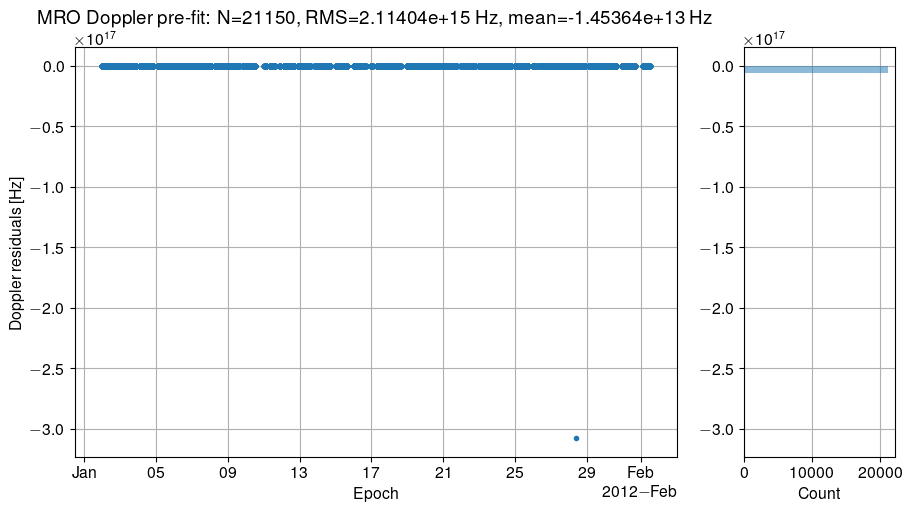

In [13]:
import numpy as np
from matplotlib import pyplot as plt
from tudatpy.astro.time_representation import DateTime

import plotting_utils as plt_utils

prefit_observation_times_dt = [
    DateTime.from_epoch(t).to_python_datetime()
    for t in compressed_observations.get_concatenated_observation_times()
]
prefit_residuals = compressed_observations.get_concatenated_residuals()
prefit_N_obs = len(prefit_residuals)
prefit_RMS = np.sqrt(np.square(prefit_residuals).mean())
prefit_mean = prefit_residuals.mean()


fig, (ax, ax_hist) = plt_utils.create_residual_timeseries_with_histogram_figure()

ax.plot(
    prefit_observation_times_dt,
    prefit_residuals,
    ".",
)
ax_hist.hist(
    prefit_residuals,
    bins=50,
    alpha=0.5,
    orientation="horizontal",
)

ax.set_title(
    f"{sc_name} Doppler pre-fit: N={prefit_N_obs}, RMS={prefit_RMS:.5e} Hz, mean={prefit_mean:.5e} Hz"
)

ax.set_ylabel("Doppler residuals [Hz]")


### Filter Outliers

We filter the residuals to remove gross outliers by applying a residual filter that only retains residuals below 20mHz.

In [14]:
# create a new observation collection to keep all original observations
filtered_observations = observations.create_new_observation_collection(
    compressed_observations
)

residual_threshold = 0.02  # abs(residuals) > 0.02 Hz
filter_residuals = observations.observations_processing.observation_filter(
    observations.observations_processing.ObservationFilterType.residual_filtering,
    residual_threshold,
)

filtered_observations.filter_observations(filter_residuals)
filtered_observations.remove_empty_observation_sets()


### Plot Filtered Residuals

We then plot the filtered residuals, which reproduces Fig. 5 of the poster.
The residuals are colored and marked by link-end configuration.
The label of the link-ends is omitted in the poster figure, see the next plot for the complete list.

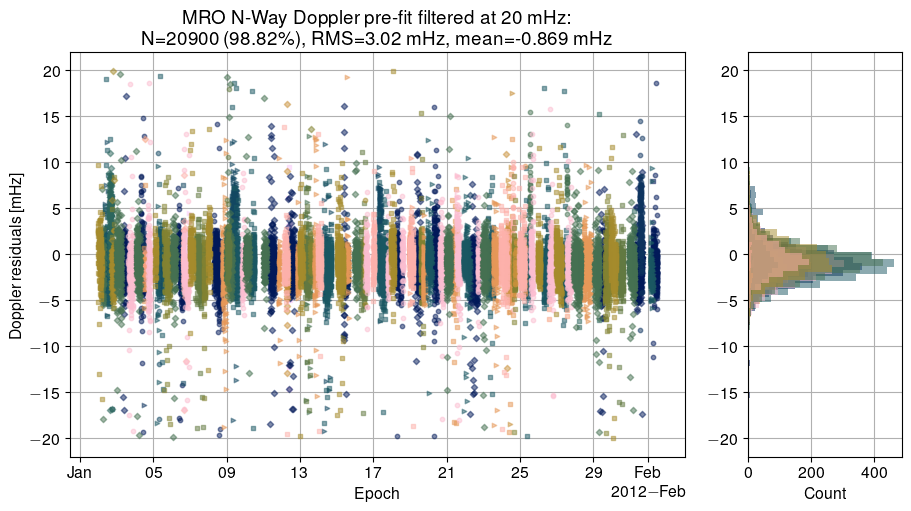

In [15]:
import plotting_utils as plt_utils

with plt.rc_context(
    {
        "axes.prop_cycle": plt_utils.default_residuals_color_cycle(15),
    }
):
    fig, (ax, ax_hist) = (
        plt_utils.plot_doppler_residuals_with_histogram_link_end_grouped(
            filtered_observations, add_legend=False
        )
    )

plt_utils.set_doppler_residual_statistic_title(
    ax,
    residual_threshold,
    filtered_observations,
    compressed_observations,
    mission_name=sc_name,
)
plt_utils.save_figure(
    fig,
    mission_output_directory
    / f"{sc_name}_doppler_prefits_filtered_{residual_threshold:.2f}Hz.png",
)

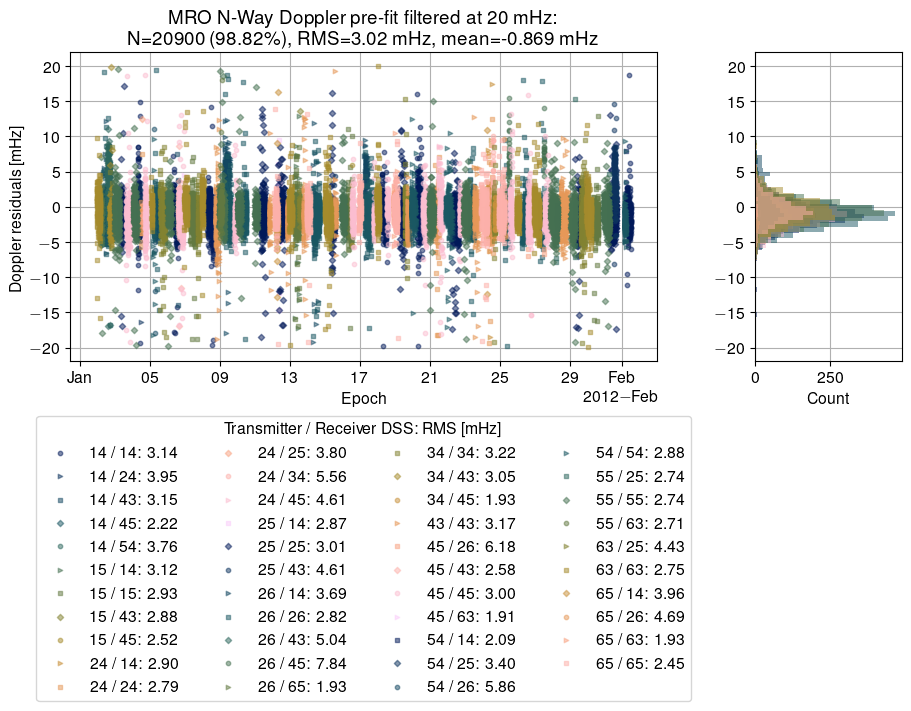

In [16]:
with plt.rc_context(
    {
        "axes.prop_cycle": plt_utils.default_residuals_color_cycle(15),
    }
):
    fig2, (ax, ax_hist) = (
        plt_utils.plot_doppler_residuals_with_histogram_link_end_grouped(
            filtered_observations, figsize=(9, 7)
        )
    )

plt_utils.set_doppler_residual_statistic_title(
    ax,
    residual_threshold,
    filtered_observations,
    compressed_observations,
    mission_name=sc_name,
)

ax.legend(
    ncols=4,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    title="Transmitter / Receiver DSS: RMS [mHz]",
)